# Setup

In [9]:
import math
import pickle as pk
import pathlib

import torch
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
import kmedoids
import seaborn as sns
import matplotlib.pyplot as plt

from data import MET_Data
import utils

In [102]:
device = "cpu"

merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n3")

def get_merge_func(index, merge_map = merge_map):
    merge_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    return merge_func

def get_model(model_path):
    experiment = utils.load_jit_folds(model_path, get_checkpoints = False)
    encoders = {fold: {modal: arms["enc"].to(device) for (modal, arms) in fold_dict["best"].model_dict.items()}
                for (fold, fold_dict) in experiment["folds"].items()}
    decoders = {fold: {modal: arms["dec"].to(device) for (modal, arms) in fold_dict["best"].model_dict.items()}
                for (fold, fold_dict) in experiment["folds"].items()}
    mappers = {fold: {tuple(modal_str.split("-")): mapper.to(device) for (modal_str, mapper) in fold_dict["best"].mappers.items()}
                     if fold_dict["best"].mappers else {}
               for (fold, fold_dict) in experiment["folds"].items()}
    return (encoders, decoders, mappers)

def get_data(sp_ids = None):
    data_paths = {
        "patchseq": "../data/patchseq.hdf5",
        "EM": "../data/EM.hdf5",
        "smartseq": "../data/smartseq.hdf5",
        "10x": "../data/10x.hdf5",
        "trunc": "../data/patch_smart_trunc.hdf5"}
    data_keys = {
        "logcpm": [["patchseq", "logcpm"], ["smartseq", "logcpm_aligned"]],
        "pca-ipfx": [["patchseq", "pca-ipfx"]],
        "arbors": [["patchseq", "arbors"], ["EM", "arbors"]]}
    met_data = MET_Data(data_paths, **data_keys)
    raw_data = met_data.query(sp_ids, formats = [("logcpm", "pca-ipfx", "arbors")])
    data = {form: torch.from_numpy(raw_data[form]).float().to(device) for form in ["logcpm", "pca-ipfx", "arbors"]}
    return (data, raw_data["specimen_id"], raw_data["cluster_label"], raw_data["met_type"])

def get_model_outputs(data, encoders, decoders, mappers):
    forms = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
    with torch.no_grad():
        modal_latent = {fold: {modal: encoder({forms[modal]:data[forms[modal]]}) for (modal, encoder) in fold_dict.items()} 
                        for (fold, fold_dict) in encoders.items()}
        mapped_recons = {fold: {(in_m, out_m): decoders[fold][out_m](mapper(modal_latent[fold][in_m][0])[0])[forms[out_m]] 
                                for ((in_m, out_m), mapper) in fold_dict.items()}
                        for (fold, fold_dict) in mappers.items()} 
        direct_recons = {fold: {(in_m, in_m): decoder(modal_latent[fold][in_m][0])[forms[in_m]] 
                                for (in_m, decoder) in fold_dict.items()}
                        for (fold, fold_dict) in decoders.items()}
        recons = {fold: {**direct_recons[fold], **mapped_recons[fold]} for fold in direct_recons}

    (means, transfs, eig_vals, eig_vecs, rotations) = ({}, {}, {}, {}, {})
    with torch.no_grad():
        for (fold, fold_dict) in recons.items():
            for (in_modal, out_modal) in fold_dict:
                (mean, transf) = modal_latent[fold][in_modal]
                modals = (in_modal, out_modal)
                if in_modal != out_modal:
                    (mean, transf) = mappers[fold][modals](mean)
                (means.setdefault(fold, {})[modals], transfs.setdefault(fold, {})[modals]) = (mean, transf)
                covs = torch.einsum("nij,nkj->nik", transf, transf)
                (eig_vals.setdefault(fold, {})[modals], eig_vecs.setdefault(fold, {})[modals]) = torch.linalg.eigh(covs)
                rotations.setdefault(fold, {})[modals] = 180*torch.atan2(eig_vecs[fold][modals][:, 1, 1], eig_vecs[fold][modals][:, 1, 0])/np.pi
    return (means, transfs, recons)

def get_euclidean_distance(z_means, source_i, target_i, **kwargs):
    diff_vectors = z_means[source_i, None] - z_means[target_i]
    dist = torch.linalg.norm(diff_vectors, dim = -1)
    return dist

def get_tree_labels(tree_children, true_labels, merge_list):
    num_samples = len(true_labels)
    parent_map = [{child_1: i, child_2: i} for (i, (child_1, child_2)) in enumerate(tree_children, num_samples)]
    cluster_indices = [np.arange(num_samples)]
    for merge_dict in parent_map:
        cluster_indices.append(np.asarray([merge_dict.get(i, i) for i in cluster_indices[-1]]))
    pred_clusters = []
    for label_merge in merge_list:
        target_labels = get_merge_func(label_merge)(true_labels)
        label_map = {label:i for (i, label) in enumerate(np.unique(target_labels))}
        pred_clusters.append(cluster_indices[-len(label_map)])
    return pred_clusters

def get_scores(true_labels, pred_labels, score_func):
    scores = {}
    for (method, method_dict) in pred_labels.items():
        for ((in_modal, out_modal), modal_dict) in method_dict.items():
            for (merge, merge_dict) in modal_dict.items():
                print(f"Generating {method} scores: {in_modal} -> {out_modal}                     ", end = "\r")
                true_merged = get_merge_func(merge)(true_labels)
                label_map = {label:i for (i, label) in enumerate(np.unique(true_merged))}
                true_indices = np.asarray([label_map[label] for label in true_merged])
                score = np.mean([score_func(true_indices, pred) for pred in merge_dict.values()])
                scores.setdefault(method, {}).setdefault((in_modal, out_modal), {})[merge] = score
    return scores

def get_silhouette(data, labels):
    form_map = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
    silhouettes = {}
    for (method, method_dict) in labels.items():
        for ((in_modal, out_modal), modal_dict) in method_dict.items():
            out_form = form_map[out_modal]
            X = data[out_form]
            for (merge, merge_dict) in modal_dict.items():
                print(f"Generating {method} silhouettes: {in_modal} -> {out_modal} merge {merge}                     ", end = "\r")
                fold_scores = [silhouette_score(X.reshape(X.shape[0], -1), label) for label in merge_dict.values()
                               if np.unique(label).size > 1]
                if fold_scores:
                    silhouettes.setdefault(method, {}).setdefault((in_modal, out_modal), {})[merge] = np.mean(fold_scores)
    return silhouettes

def load_labels(label_path, methods = None, modals = None):
    with open(label_path, "rb") as target:
        results = pk.load(target)
        (pred_labels, sp_ids) = (results["pred_labels"], results["specimen_ids"])
        (t_type, met_type) = get_data(sp_ids)[2:]
        pred_labels = {method: dct for (method, dct) in pred_labels.items() if not methods or method in methods}
        for method in pred_labels:
            pred_labels[method] = {modal: dct for (modal, dct) in pred_labels[method].items() if not modals or modal in modals}
    return (sp_ids, pred_labels, t_type, met_type)

# Latent Visualization

In [103]:

(encoders, decoders, mappers) = get_model("../results/old_results/baselines/met_10d_mse")
(sp_ids, pred_labels, t_type, met_type) = load_labels("../results/clustering/dijkstra_baseline.pk")
(data, _, t_type, met_type) = get_data(sp_ids)
(means, transfs, recons) = get_model_outputs(data, encoders, decoders, mappers)



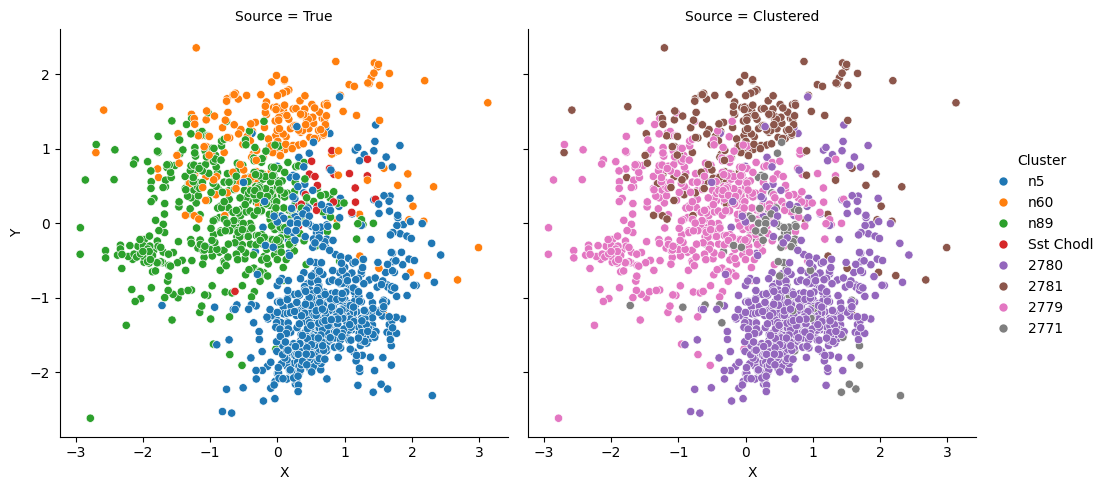

In [104]:
modals = ("T", "T")
fold = 3
merge = 99
method = "eucl"

true_merged = get_merge_func(merge)(t_type)
pred_merged = pred_labels[method][modals][merge][fold]
latent = means[fold][modals]
sns.relplot({"X": np.tile(latent[:, 0], 2), "Y": np.tile(latent[:, 1], 2), 
             "Cluster": np.concatenate([true_merged, pred_merged]), "Source": len(latent)*["True"] + len(latent)*["Clustered"]},
            x = "X", y = "Y", hue = "Cluster", col = "Source")
plt.show()

# Weighting

In [ ]:
(score_name, score_func) = ("Rand Score", adjusted_rand_score)
cluster_paths = {
    "1": "../data/clustering/cluster_1_10d.pk",
    "1/2": "../data/clustering/cluster_2_10d.pk",
    "1/10": "../data/clustering/cluster_10_10d.pk",
    "1/100": "../data/clustering/cluster_100_10d.pk",
    "0": "../data/clustering/cluster_allt_10d.pk",
    "Unimodal": "../data/clustering/cluster_t_10d.pk"}
labels = {weight: load_labels(path, modals = {("T", "T")}) for (weight, path) in cluster_paths.items()}

## Rand Scores

In [6]:
scores = {weight: get_scores(true, pred, score_func) for (weight, (pred, true)) in labels.items()}

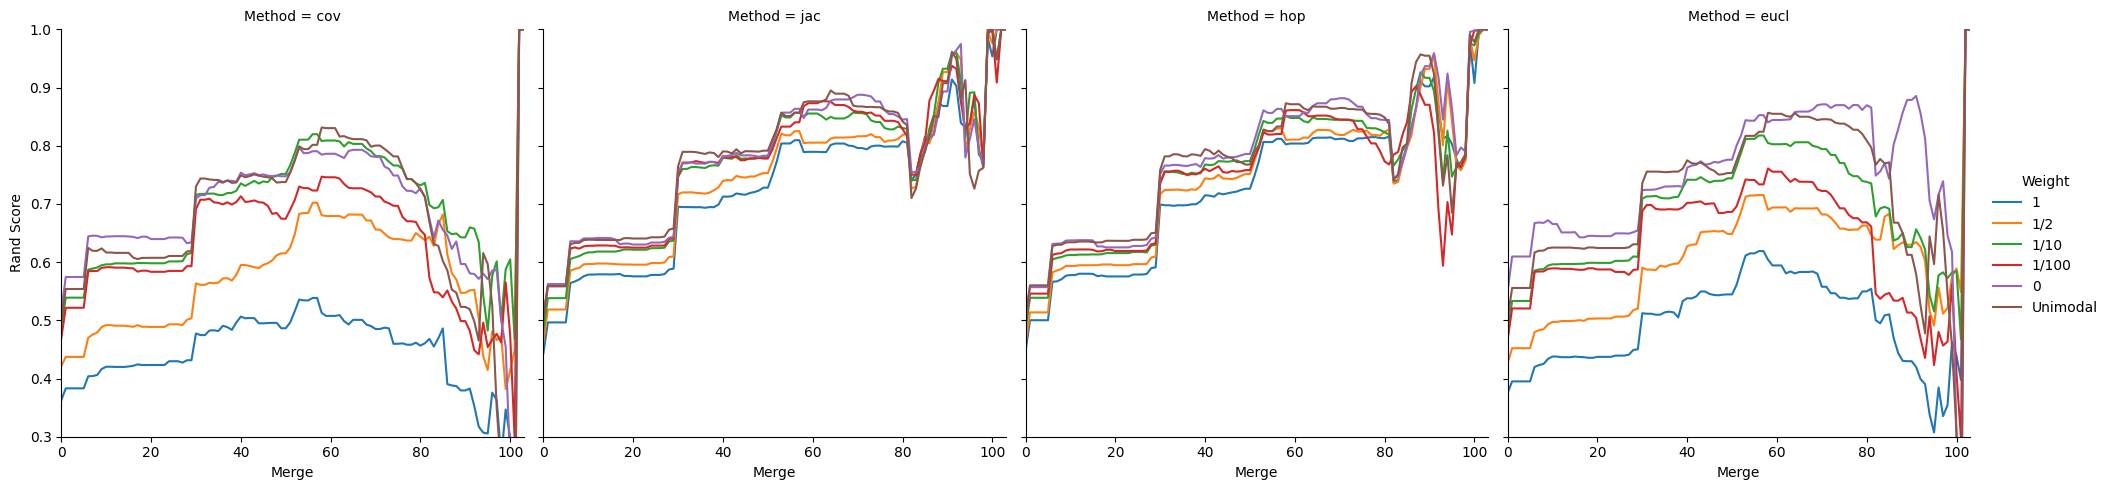

In [170]:
plot_data = {"Merge": [], score_name: [], "Weight": [], "Method": []}
for (weight, method_dict) in scores.items():
    for (method, modal_dict) in method_dict.items():
        if method == "raw": continue
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data[score_name].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = score_name, hue = "Weight", col = "Method", kind = "line")
for ax in plot.figure.axes:
    ax.set_xlim((0, 103))
    ax.set_ylim((0.3, 1.0))
plt.show()

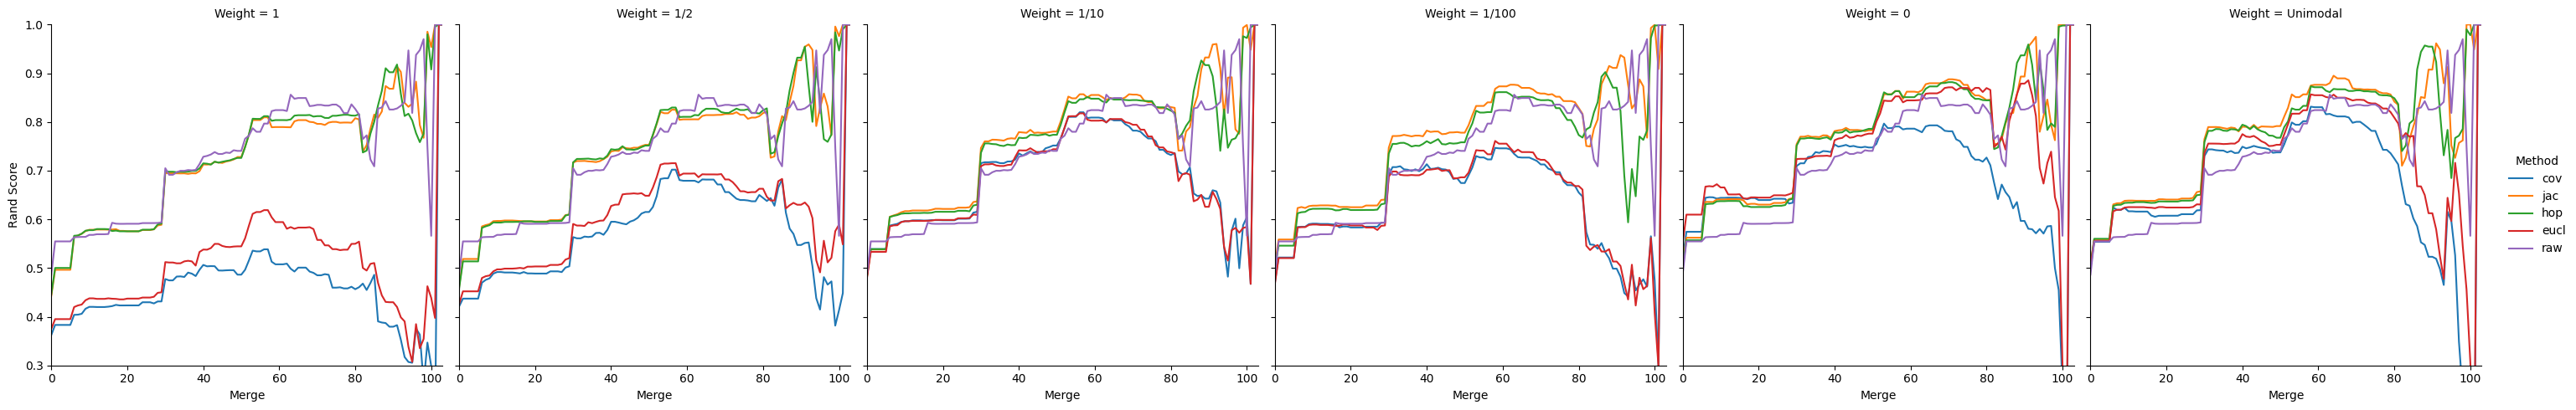

In [5]:
plot_data = {"Merge": [], score_name: [], "Weight": [], "Method": []}
for (weight, method_dict) in scores.items():
    for (method, modal_dict) in method_dict.items():
        # if method == "raw": continue
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data[score_name].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = score_name, hue = "Method", col = "Weight", kind = "line")
for ax in plot.figure.axes:
    ax.set_xlim((0, 103))
    ax.set_ylim((0.3, 1.0))
plt.show()

## Silhouette

In [69]:
silhouettes = {weight: get_silhouette(data["logcpm"], pred) for (weight, (pred, _)) in labels.items()}

In [ ]:
t_type_silhouettes = {}
for merge in labels["Unimodal"][0]["cov"][("T", "T")]:
    true_merged = get_merge_func(merge)(cluster_labels)
    label_map = {label:i for (i, label) in enumerate(np.unique(true_merged))}
    true_indices = np.asarray([label_map[label] for label in true_merged])
    if len(label_map) > 1:
        t_type_silhouettes[merge] = silhouette_score(data["logcpm"], true_indices)

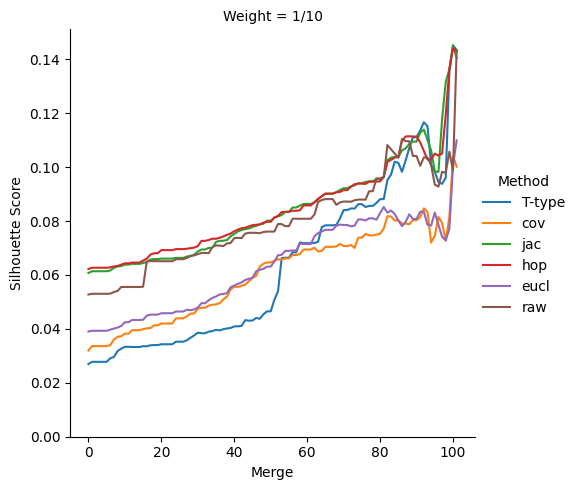

In [73]:
plot_data = {"Silhouette Score": list(t_type_silhouettes.values()), "Merge": list(t_type_silhouettes), 
             "Method": len(t_type_silhouettes)*["T-type"], "Weight": len(t_type_silhouettes)*["1/10"]}
for (weight, method_dict) in silhouettes.items():
    if weight != "1/10": continue
    for (method, modal_dict) in method_dict.items():
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data["Silhouette Score"].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = "Silhouette Score", hue = "Method", col = "Weight", kind = "line")
for ax in plot.figure.axes:
    ax.set_ylim((-0.00, None))
plt.show()

## MET-Type and T-Type

In [105]:
(score_name, score_func) = ("Rand Score", adjusted_rand_score)
(sp_ids, pred_label, t_type, met_type) = load_labels("../results/clustering/dijkstra_tenth.pk")
(data, _, t_type, met_type) = get_data(sp_ids)
silhouettes = get_silhouette(data, pred_label)

In [106]:
t_type_silhouettes = {}
for form in ["logcpm", "pca-ipfx", "arbors"]:
    X = data[form]
    for merge in pred_label["cov"][("T", "T")]:
        true_merged = get_merge_func(merge)(t_type)
        label_map = {label:i for (i, label) in enumerate(np.unique(true_merged))}
        true_indices = np.asarray([label_map[label] for label in true_merged])
        if len(label_map) > 1:
            t_type_silhouettes.setdefault(form, {})[merge] = silhouette_score(X.reshape(X.shape[0], -1), true_indices)

In [107]:
label_map = {label:i for (i, label) in enumerate(np.unique(met_type))}
true_indices = np.asarray([label_map[label] for label in met_type if label != "nan"])
met_type_silhouettes = {}
for form in ["logcpm", "pca-ipfx", "arbors"]:
    X = data[form][met_type != "nan"]
    if len(label_map) > 1:
        met_type_silhouettes[form] = silhouette_score(X.reshape(X.shape[0], -1), true_indices)

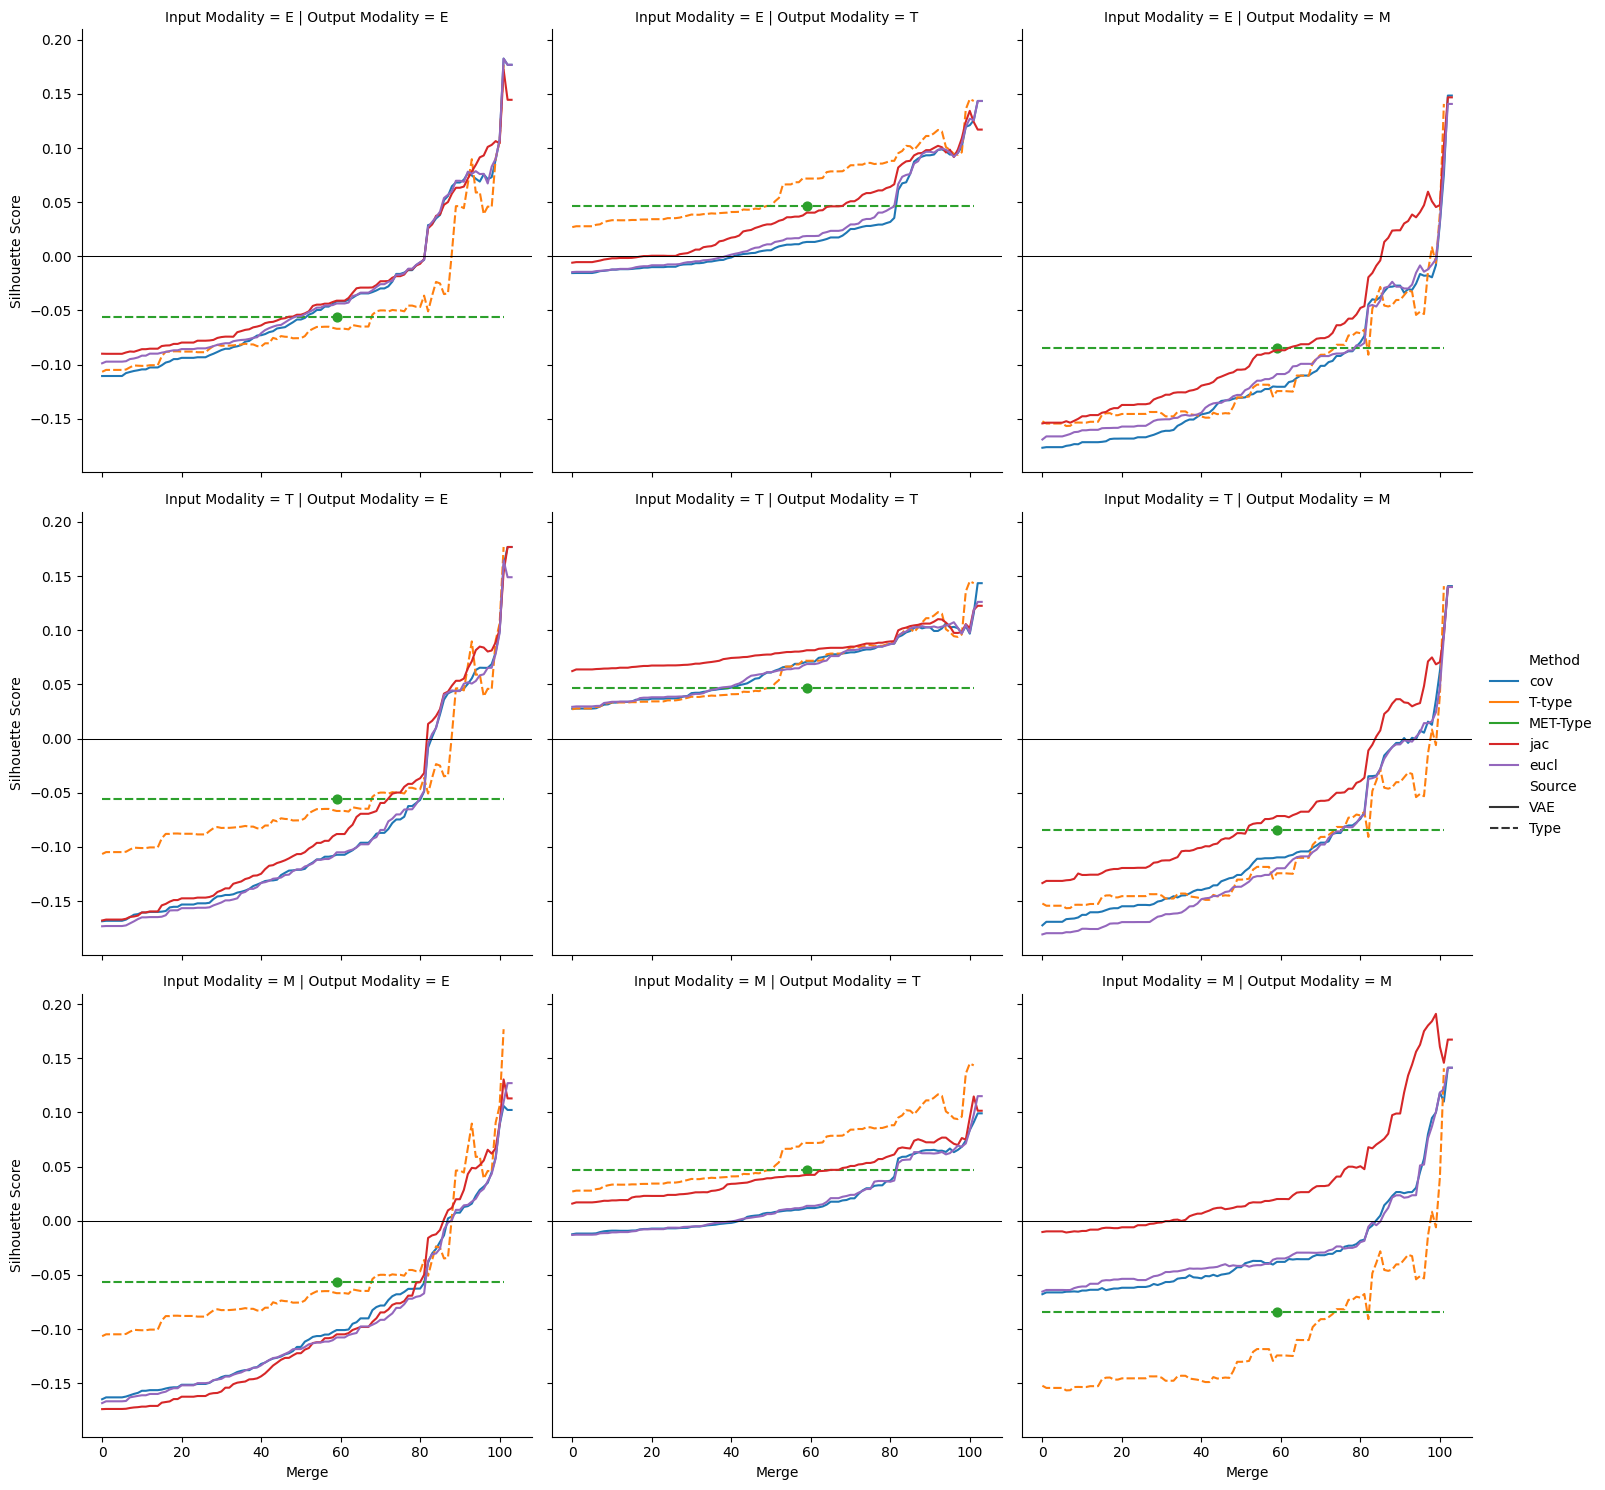

In [108]:
form_map = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
plot_data = {"Silhouette Score": [], "Input Modality": [], "Output Modality": [], "Merge": [], "Method": [], "Source": []}
add_labels = True
for (method, modal_dict) in silhouettes.items():
    if method == "raw": continue
    for ((in_modal, out_modal), score_dict) in modal_dict.items():
        for (merge, score) in score_dict.items():
            plot_data["Input Modality"].append(in_modal)
            plot_data["Output Modality"].append(out_modal)
            plot_data["Merge"].append(merge)
            plot_data["Silhouette Score"].append(score)
            plot_data["Method"].append(method)
            plot_data["Source"].append("VAE")
            form = form_map[out_modal]
            if add_labels and merge in t_type_silhouettes[form]:
                scores = [t_type_silhouettes[form][merge], met_type_silhouettes[form]]
                plot_data["Input Modality"].extend(2*[in_modal])
                plot_data["Output Modality"].extend(2*[out_modal])
                plot_data["Merge"].extend(2*[merge])
                plot_data["Silhouette Score"].extend(scores)
                plot_data["Method"].extend(["T-type", "MET-Type"])
                plot_data["Source"].extend(["Type", "Type"])
    add_labels = False
plot = sns.relplot(plot_data, x = "Merge", y = "Silhouette Score", hue = "Method", row = "Input Modality", col = "Output Modality", style = "Source",
                   kind = "line")
for (ax_set, out_form) in zip(plot.axes.T, ["pca-ipfx", "logcpm", "arbors"]):
    for ax in ax_set:
        ax.scatter([max(plot_data["Merge"]) - np.unique(met_type).size + 1], [met_type_silhouettes[out_form]], c = "C2", s = 40)
for ax in plot.figure.axes:
    ax.axhline(0, 0, 100, color = "black", linewidth = 0.75)
#     ax.set_ylim((-0.00, None))
plt.show()

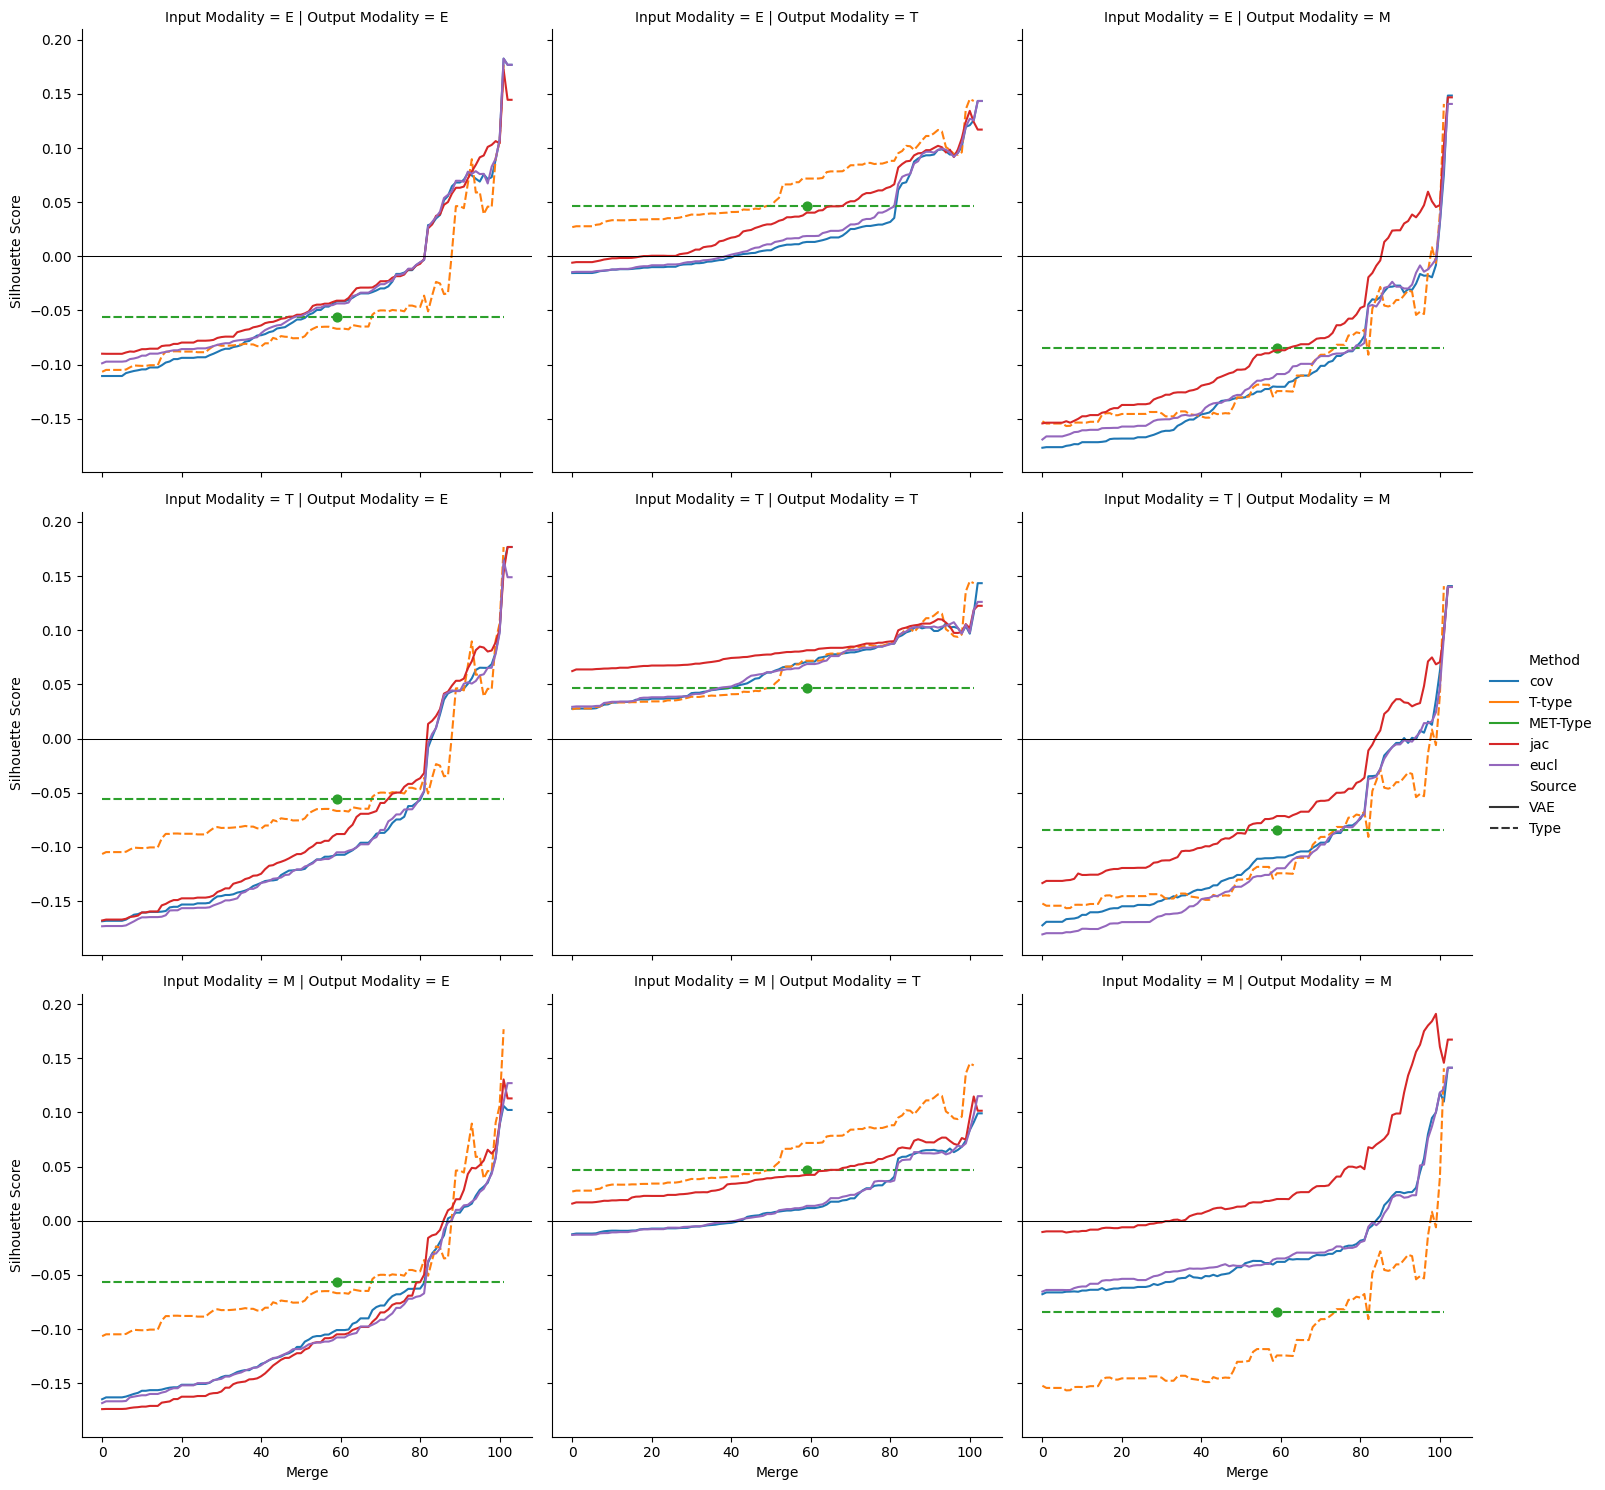

In [ ]:
form_map = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
plot_data = {"Silhouette Score": [], "Input Modality": [], "Output Modality": [], "Merge": [], "Method": [], "Source": []}
add_labels = True
for (method, modal_dict) in silhouettes.items():
    if method == "raw": continue
    for ((in_modal, out_modal), score_dict) in modal_dict.items():
        for (merge, score) in score_dict.items():
            plot_data["Input Modality"].append(in_modal)
            plot_data["Output Modality"].append(out_modal)
            plot_data["Merge"].append(merge)
            plot_data["Silhouette Score"].append(score)
            plot_data["Method"].append(method)
            plot_data["Source"].append("VAE")
            form = form_map[out_modal]
            if add_labels and merge in t_type_silhouettes[form]:
                scores = [t_type_silhouettes[form][merge], met_type_silhouettes[form]]
                plot_data["Input Modality"].extend(2*[in_modal])
                plot_data["Output Modality"].extend(2*[out_modal])
                plot_data["Merge"].extend(2*[merge])
                plot_data["Silhouette Score"].extend(scores)
                plot_data["Method"].extend(["T-type", "MET-Type"])
                plot_data["Source"].extend(["Type", "Type"])
    add_labels = False
plot = sns.relplot(plot_data, x = "Merge", y = "Silhouette Score", hue = "Method", row = "Input Modality", col = "Output Modality", style = "Source",
                   kind = "line")
for (ax_set, out_form) in zip(plot.axes.T, ["pca-ipfx", "logcpm", "arbors"]):
    for ax in ax_set:
        ax.scatter([max(plot_data["Merge"]) - np.unique(met_type).size + 1], [met_type_silhouettes[out_form]], c = "C2", s = 40)
for ax in plot.figure.axes:
    ax.axhline(0, 0, 100, color = "black", linewidth = 0.75)
#     ax.set_ylim((-0.00, None))
plt.show()